In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics

from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/chili_final_finetune_dataset/chili_leaf_model_v1.pt")

model.train(
    data="/content/drive/MyDrive/chili_final_finetune_dataset/data.yaml",

    epochs=100,
    imgsz=640,
    batch=8,

    lr0=0.0003,
    optimizer="AdamW",
    patience=20,

    augment=True,

    project="/content/drive/MyDrive/chili_results",
    name="chili_finetuned_v2",
    exist_ok=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/chili_final_finetune_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/co

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc869460110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to the results.csv file
results_path = '/content/drive/MyDrive/chili_results/chili_finetuned_v2/results.csv'

# Load the results into a pandas DataFrame
results_df = pd.read_csv(results_path)

# Display the first few rows and columns to understand the data
print("Results DataFrame head:")
display(results_df.head())
print("Results DataFrame columns:")
print(results_df.columns)

Results DataFrame head:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,11.7610,1.15541,1.19507,1.57626,0.53014,0.63858,0.60464,0.26239,2.05697,1.96567,2.76870,0.000097,0.000097,0.067598
1,2,22.2938,1.08002,1.12534,1.49773,0.78080,0.82102,0.85826,0.55527,1.38018,0.97906,2.08820,0.000196,0.000196,0.034362
2,3,47.3812,1.05434,1.01040,1.47938,0.87570,0.79166,0.86754,0.53532,1.40709,0.96946,2.11191,0.000292,0.000292,0.001125
3,4,61.4936,0.98585,0.98325,1.40263,0.82139,0.86654,0.90152,0.58173,1.30912,0.93446,2.00757,0.000291,0.000291,0.000291
4,5,77.4548,1.02609,0.96104,1.45832,0.92606,0.83221,0.90478,0.58332,1.25186,0.86972,2.01323,0.000288,0.000288,0.000288


Results DataFrame columns:
Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


Now let's plot the training and validation metrics. We'll focus on loss values (box_loss, cls_loss, dfl_loss) and performance metrics (precision, recall, mAP50, mAP50-95).

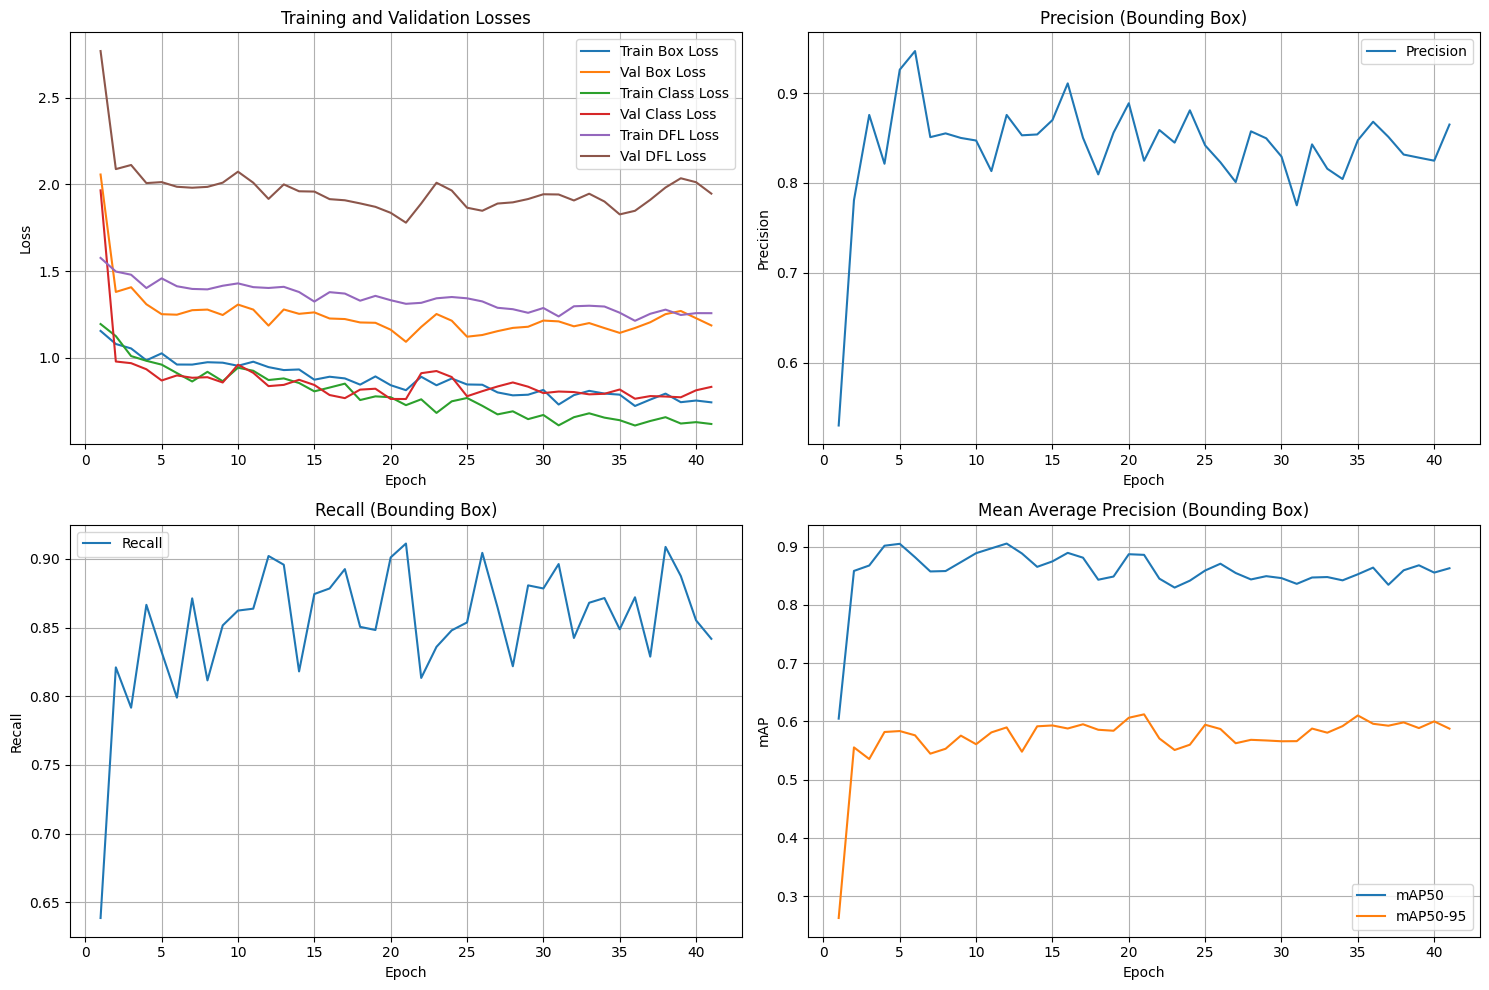

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Plot Loss Metrics
axes[0, 0].plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
axes[0, 0].plot(results_df['epoch'], results_df['val/box_loss'], label='Val Box Loss')
axes[0, 0].plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss')
axes[0, 0].plot(results_df['epoch'], results_df['val/cls_loss'], label='Val Class Loss')
axes[0, 0].plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train DFL Loss')
axes[0, 0].plot(results_df['epoch'], results_df['val/dfl_loss'], label='Val DFL Loss')
axes[0, 0].set_title('Training and Validation Losses')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot Precision
axes[0, 1].plot(results_df['epoch'], results_df['metrics/precision(B)'], label='Precision')
axes[0, 1].set_title('Precision (Bounding Box)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot Recall
axes[1, 0].plot(results_df['epoch'], results_df['metrics/recall(B)'], label='Recall')
axes[1, 0].set_title('Recall (Bounding Box)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot mAP
axes[1, 1].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP50')
axes[1, 1].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1, 1].set_title('Mean Average Precision (Bounding Box)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mAP')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Run Inference on a New Image

Now that the model is trained, let's test it on a new image. You'll need to specify the path to an image file in your Google Drive.

In [ ]:
import os
from PIL import Image

# Define the path to a test image
# IMPORTANT: Replace this with the actual path to your test image in Google Drive
test_image_path = '/content/drive/MyDrive/chili_final_finetune_dataset/test_images/test_image_1.jpg' # Example path

# Check if the image file exists
if not os.path.exists(test_image_path):
    print(f"Error: The image file '{test_image_path}' does not exist.")
    print("Please verify the path to your test image in Google Drive. Here are the contents of the specified directory if it exists:")
    test_images_dir = os.path.dirname(test_image_path)
    if os.path.exists(test_images_dir) and os.path.isdir(test_images_dir):
        print(f"Contents of '{test_images_dir}':")
        for item in os.listdir(test_images_dir):
            print(f"- {item}")
    else:
        print(f"The directory '{test_images_dir}' also does not exist or is not a directory.")
else:
    # Perform inference on the image
    # The 'model' object is already loaded from the training cell (xYSyNfxs5GI6)
    results = model(test_image_path)

    # Display the results
    # The results object contains predictions, and it can directly plot bounding boxes
    # and labels on the image.

    # For visualization, Ultralytics stores the annotated image in the 'results' object
    # and we can plot it directly.
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        display(im)

    print("Inference complete. The annotated image is displayed above.")

Error: The image file '/content/drive/MyDrive/chili_final_finetune_dataset/test_images/test_image_1.jpg' does not exist.
Please verify the path to your test image in Google Drive. Here are the contents of the specified directory if it exists:
The directory '/content/drive/MyDrive/chili_final_finetune_dataset/test_images' also does not exist or is not a directory.


### Load the best trained model and run inference on a local image

First, define the path to your `best.pt` model and the path to the local image you want to test. Ensure these paths are correct for your Google Drive setup.

In [ ]:
import os
from ultralytics import YOLO
from PIL import Image # Ensure PIL is imported for image display

# Define the path to your best.pt model
best_model_path = '/content/drive/MyDrive/chili_results/chili_finetuned_v2/weights/best.pt'

# Load the best model
best_model = YOLO(best_model_path)

# Define the path to a *new* local image for inference
# IMPORTANT: Replace this with the actual path to your image file in Google Drive
local_image_path = '/content/drive/MyDrive/chili_final_finetune_dataset/test_images/test_image_1.jpg' # Example path

# Check if the local image file exists
if not os.path.exists(local_image_path):
    print(f"Error: The local image file '{local_image_path}' does not exist.")
    print("Please verify the path to your local image in Google Drive. Here are the contents of the specified directory if it exists:")
    local_image_dir = os.path.dirname(local_image_path)
    if os.path.exists(local_image_dir) and os.path.isdir(local_image_dir):
        print(f"Contents of '{local_image_dir}':")
        for item in os.listdir(local_image_dir):
            print(f"- {item}")
    else:
        print(f"The directory '{local_image_dir}' also does not exist or is not a directory.")
else:
    # Perform inference using the loaded 'best_model'
    results_best_model = best_model(local_image_path)

    # Display the results
    for r in results_best_model:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        display(im)

    print("Inference complete with 'best.pt' model. The annotated image is displayed above.")

Error: The local image file '/content/drive/MyDrive/chili_final_finetune_dataset/test_images/test_image_1.jpg' does not exist.
Please verify the path to your local image in Google Drive. Here are the contents of the specified directory if it exists:
The directory '/content/drive/MyDrive/chili_final_finetune_dataset/test_images' also does not exist or is not a directory.


In [ ]:
import os

# Let's check the contents of the main dataset folder to find the correct path
parent_dir = '/content/drive/MyDrive/chili_final_finetune_dataset/'

if os.path.exists(parent_dir):
    print(f"Contents of {parent_dir}:")
    for item in os.listdir(parent_dir):
        print(f"- {item}")
else:
    print(f"The directory {parent_dir} was not found. Please check your Google Drive manually to confirm the folder name.")

Contents of /content/drive/MyDrive/chili_final_finetune_dataset/:
- chili_leaf_model_v1.pt
- data.yaml
- images
- labels


In [ ]:
# This cell is no longer needed as 'from PIL import Image' has been moved to the inference cell.